In [1]:
!unzip apple_dataset.zip -d /content/datasets/apple
!unzip banana_dataset.zip -d /content/datasets/banana
!unzip carrots_dataset.zip -d /content/datasets/carrots
!unzip tomatoes_dataset.zip -d /content/datasets/tomatoes
!unzip bell_dataset.zip -d /content/datasets/bell
!unzip bitter_dataset.zip -d /content/datasets/bitter

Streaming output truncated to the last 5000 lines.
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (2).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (2).png  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (20).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (21).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (22).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (23).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (24).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (25).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (26).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (27).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (28).jpg  
  inflating: /content/datasets/banana/banana_dataset/1 days/one day (29).jpg  
  i

In [2]:
import os
import shutil

base_dir = '/content/datasets'
combined_dir = '/content/combined_dataset'
os.makedirs(combined_dir, exist_ok=True)

foods = ['apple', 'banana', 'carrots', 'tomatoes', 'bell', 'bitter']

food_stages = {
    'apple': ['1-3 days', '4-6 days', '7-9 days', '10-12 days', '13-15 days'],
    'banana': ['1 days', '2 days', '3 days', '4 days', '5 days', '6 days', '7 days'],
    'bell': ['1-2 days', '3 days', '4 days', '5 days', '6-7 days'],
    'bitter': ['1 days', '2 days', '3 days', '4 days'],
    'carrots': ['1-2 days', '3 days', '4-5 days', '6-7 days'],
    'tomatoes': ['1-2 days', '3-5 days', '6-7 days', '8-11 days', '11-14 days']
}

for food in foods:
    food_path = os.path.join(base_dir, food)
    if os.path.exists(food_path):
        nested_folder = None
        for item in os.listdir(food_path):
            full_path = os.path.join(food_path, item)
            if os.path.isdir(full_path) and item.lower() == f"{food}_dataset".lower():
                nested_folder = full_path
                break
        if nested_folder:
            actual_stages = [d for d in os.listdir(nested_folder) if os.path.isdir(os.path.join(nested_folder, d))]
        else:
            actual_stages = [d for d in os.listdir(food_path) if os.path.isdir(os.path.join(food_path, d))]
        print(f"Checking {food}: Nested folder? {nested_folder}, Expected stages: {food_stages[food]}, Actual stages: {actual_stages}")
        for stage in food_stages[food]:
            src = os.path.join(nested_folder if nested_folder else food_path, stage)
            if os.path.exists(src):
                dst_class = f"{food}_{stage}"
                dst = os.path.join(combined_dir, dst_class)
                os.makedirs(dst, exist_ok=True)
                for img in os.listdir(src):
                    if os.path.isfile(os.path.join(src, img)):
                        shutil.copy(os.path.join(src, img), os.path.join(dst, img))
            else:
                print(f"Warning: {src} not found for {food}")

print("Combined dataset classes:", os.listdir(combined_dir))

Checking apple: Nested folder? /content/datasets/apple/apple_dataset, Expected stages: ['1-3 days', '4-6 days', '7-9 days', '10-12 days', '13-15 days'], Actual stages: ['13-15 days', '4-6 days', '7-9 days', '10-12 days', '1-3 days']
Checking banana: Nested folder? /content/datasets/banana/banana_dataset, Expected stages: ['1 days', '2 days', '3 days', '4 days', '5 days', '6 days', '7 days'], Actual stages: ['1 days', '2 days', '4 days', '3 days', '6 days', '5 days', '7 days']
Checking carrots: Nested folder? /content/datasets/carrots/carrots_dataset, Expected stages: ['1-2 days', '3 days', '4-5 days', '6-7 days'], Actual stages: ['1-2 days', '3 days', '6-7 days', '4-5 days']
Checking tomatoes: Nested folder? /content/datasets/tomatoes/tomatoes_dataset, Expected stages: ['1-2 days', '3-5 days', '6-7 days', '8-11 days', '11-14 days'], Actual stages: ['1-2 days', '6-7 days', '8-11 days', '11-14 days', '3-5 days']
Checking bell: Nested folder? /content/datasets/bell/bell_dataset, Expected 

Starting Enhanced Food Ripeness Classification Training...
Found 5100 images belonging to 30 classes.
Found 900 images belonging to 30 classes.
Training samples: 5100
Validation samples: 900
Number of classes: 30
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model created successfully!
Total parameters: 8,637,719
Class weights computed for balanced training

PHASE 1: Training with frozen base model


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.4036 - loss: 2.7506
Epoch 1: val_accuracy improved from -inf to 0.69778, saving model to best_enhanced_model.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 329s 968ms/step - accuracy: 0.4040 - loss: 2.7487 - val_accuracy: 0.6978 - val_loss: 1.4741 - learning_rate: 0.0010
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.6994 - loss: 1.5053
Epoch 2: val_accuracy improved from 0.69778 to 0.71667, saving model to best_enhanced_model.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 309s 969ms/step - accuracy: 0.6994 - loss: 1.5053 - val_accuracy: 0.7167 - val_loss: 1.4364 - learning_rate: 0.0010
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.7283 - loss: 1.4053
Epoch 3: val_accuracy did not improve from 0.71667
319/319 ━━━━━━━━━━━━━━━━━━━━ 305s 955ms/step - accuracy: 0.7283 - loss: 1.4053 - val_accuracy: 0.7056 - val_loss: 1.4812 - learning_rate: 0.0010
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - a

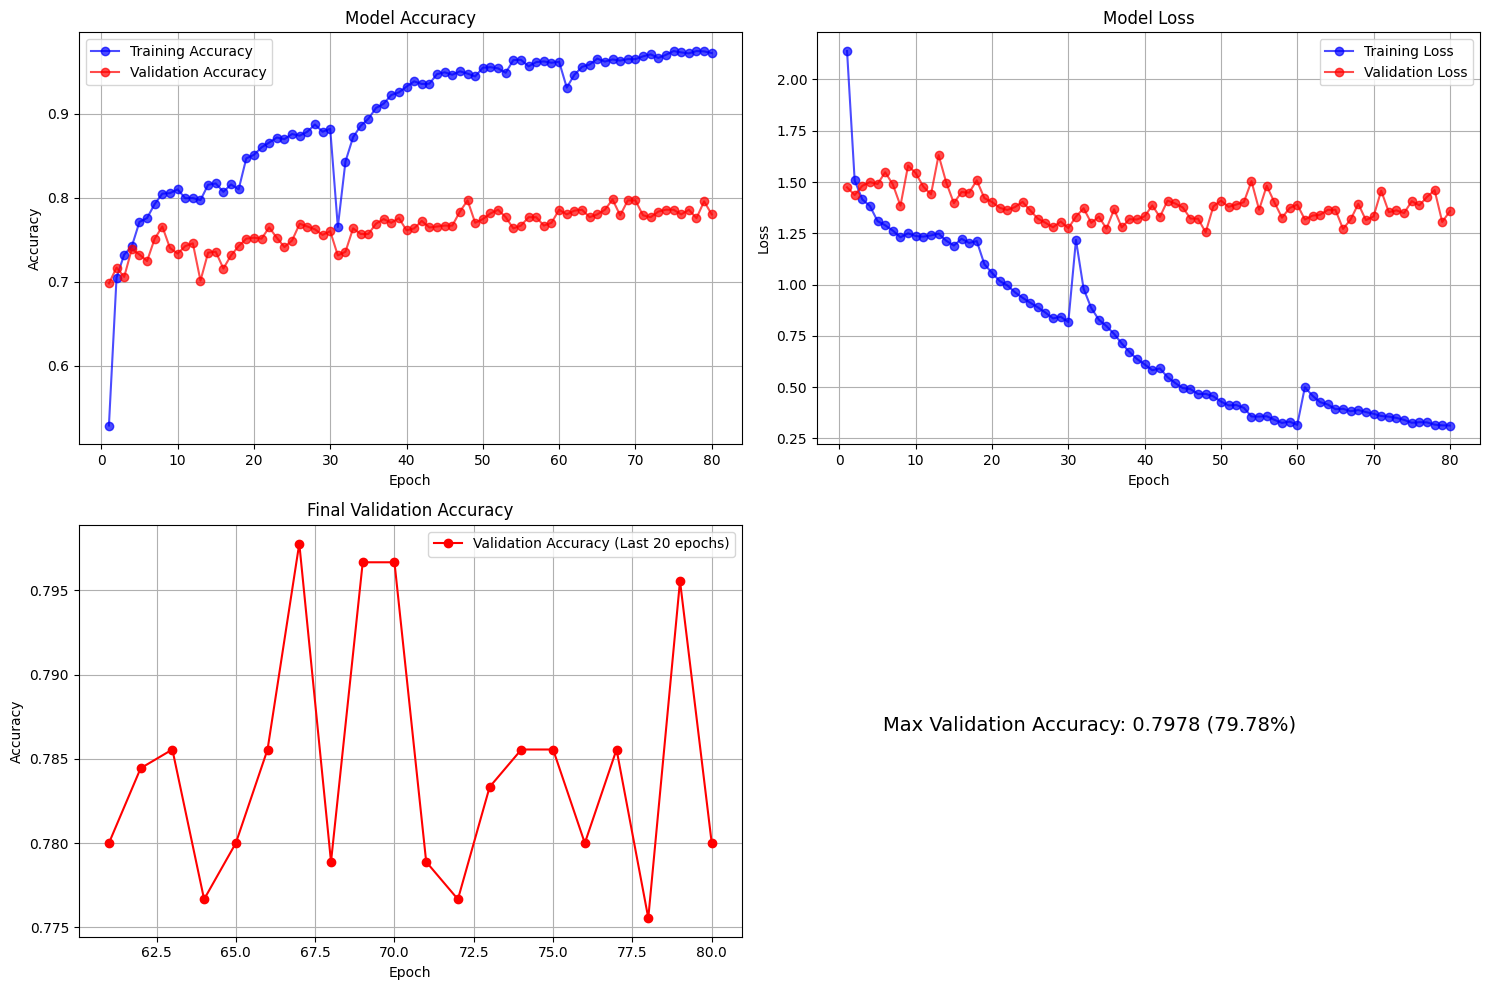


Classification Report:
                     precision    recall  f1-score   support

     apple_1-3 days       0.73      0.63      0.68        30
   apple_10-12 days       0.79      0.63      0.70        30
   apple_13-15 days       0.72      0.87      0.79        30
     apple_4-6 days       0.67      0.47      0.55        30
     apple_7-9 days       0.68      1.00      0.81        30
      banana_1 days       0.62      1.00      0.77        30
      banana_2 days       0.62      0.17      0.26        30
      banana_3 days       0.87      0.90      0.89        30
      banana_4 days       0.76      0.87      0.81        30
      banana_5 days       0.66      0.63      0.64        30
      banana_6 days       0.68      0.63      0.66        30
      banana_7 days       0.87      0.90      0.89        30
      bell_1-2 days       0.94      1.00      0.97        30
        bell_3 days       1.00      1.00      1.00        30
        bell_4 days       1.00      1.00      1.00        30

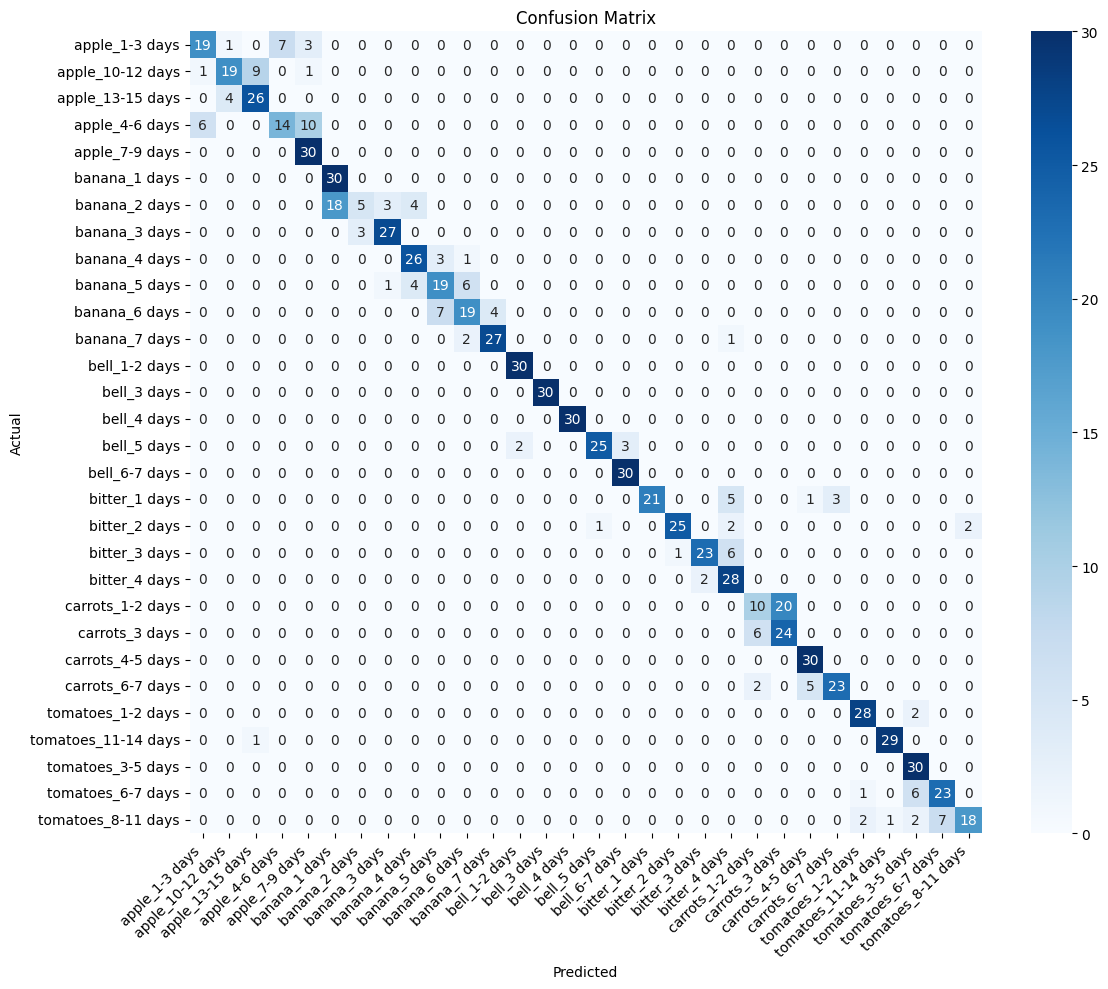


TRAINING COMPLETE!
Final Validation Accuracy: 79.78%
Advanced TTA Accuracy: 79.78%
Model saved as 'final_food_ripeness_model.keras'



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: final_food_ripeness_model.keras


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: best_enhanced_model_phase2.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: final_enhanced_model.keras

Successfully downloaded 4 model files


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from google.colab import files
import os

def preprocess_input_efficientnet(x):
    return tf.keras.applications.efficientnet.preprocess_input(x)

def create_enhanced_generators():
    datagen_train = ImageDataGenerator(
        preprocessing_function=preprocess_input_efficientnet,
        validation_split=0.15,  # More training data
        rotation_range=25,      # Reduced aggression
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.1,
        zoom_range=[0.85, 1.15],
        horizontal_flip=True,
        fill_mode='nearest',
        brightness_range=[0.8, 1.2],  # More conservative
        rescale=None,
    )

    datagen_val = ImageDataGenerator(
        preprocessing_function=preprocess_input_efficientnet,
        validation_split=0.15
    )

    train_generator = datagen_train.flow_from_directory(
        '/content/combined_dataset',
        target_size=(160, 160),
        batch_size=16,  # Smaller batch for better gradients
        class_mode='categorical',
        subset='training',
        shuffle=True,
        seed=42
    )

    val_generator = datagen_val.flow_from_directory(
        '/content/combined_dataset',
        target_size=(160, 160),
        batch_size=16,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=42
    )

    return train_generator, val_generator

def create_enhanced_model(num_classes=30):
    base_model = EfficientNetB2(weights='imagenet', include_top=False, input_shape=(160, 160, 3))

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model, base_model

class CosineAnnealingScheduler(tf.keras.callbacks.Callback):
    def __init__(self, T_max, eta_min=0, verbose=0):
        super(CosineAnnealingScheduler, self).__init__()
        self.T_max = T_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        if not hasattr(self.model.optimizer, 'learning_rate'):
            raise ValueError('Optimizer must have a "learning_rate" attribute.')

        lr = self.eta_min + (self.model.optimizer.learning_rate - self.eta_min) * \
             (1 + np.cos(np.pi * epoch / self.T_max)) / 2

        tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)

        if self.verbose > 0:
            print(f'\nEpoch {epoch + 1}: CosineAnnealingScheduler setting learning rate to {lr:.7f}.')

def compute_class_weights(train_gen):
    """Compute balanced class weights to handle any imbalance"""
    class_counts = np.bincount(train_gen.classes)
    total_samples = len(train_gen.classes)

    class_weights = {}
    for i, count in enumerate(class_counts):
        if count > 0:
            class_weights[i] = total_samples / (len(class_counts) * count)
        else:
            class_weights[i] = 1.0

    return class_weights
def create_enhanced_callbacks():
    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=20,  # Increased patience
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.2,   # More gentle reduction
            patience=10,  # Increased patience
            min_lr=1e-8,
            mode='max',
            verbose=1
        ),
        ModelCheckpoint(
            'best_enhanced_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]
    return callbacks

def train_enhanced_model():
    train_gen, val_gen = create_enhanced_generators()

    print(f"Training samples: {train_gen.samples}")
    print(f"Validation samples: {val_gen.samples}")
    print(f"Number of classes: {len(train_gen.class_indices)}")

    model, base_model = create_enhanced_model(len(train_gen.class_indices))

    print("Model created successfully!")
    print(f"Total parameters: {model.count_params():,}")

    # Compute class weights for balanced training
    class_weights = compute_class_weights(train_gen)
    print("Class weights computed for balanced training")

    print("\n" + "="*50)
    print("PHASE 1: Training with frozen base model")
    print("="*50)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_phase1 = create_enhanced_callbacks()

    history1 = model.fit(
        train_gen,
        epochs=30,  # Increased epochs
        validation_data=val_gen,
        callbacks=callbacks_phase1,
        class_weight=class_weights,  # Use class weights
        verbose=1
    )

    print("\n" + "="*50)
    print("PHASE 2: Fine-tuning top layers")
    print("="*50)

    for layer in base_model.layers[-80:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=0.0002),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_phase2 = [
        EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=12, min_lr=1e-8, mode='max'),
        ModelCheckpoint('best_enhanced_model_phase2.keras', monitor='val_accuracy', save_best_only=True, mode='max')
    ]

    history2 = model.fit(
        train_gen,
        epochs=30,  # Increased epochs
        validation_data=val_gen,
        callbacks=callbacks_phase2,
        class_weight=class_weights,  # Use class weights
        verbose=1
    )

    print("\n" + "="*50)
    print("PHASE 3: Final fine-tuning")
    print("="*50)

    for layer in base_model.layers[-150:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=0.00005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_phase3 = [
        EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=15, min_lr=1e-9, mode='max'),
        ModelCheckpoint('final_enhanced_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')
    ]

    history3 = model.fit(
        train_gen,
        epochs=20,  # Increased epochs
        validation_data=val_gen,
        callbacks=callbacks_phase3,
        class_weight=class_weights,  # Use class weights
        verbose=1
    )

    return model, [history1, history2, history3], train_gen, val_gen

def advanced_tta_evaluation(model, num_augmentations=20):  # Increased TTA
    print(f"\nPerforming Advanced TTA with {num_augmentations} augmentations...")

    tta_configs = [
        {},  # Original
        {'horizontal_flip': True},
        {'rotation_range': 5}, {'rotation_range': -5},
        {'rotation_range': 10}, {'rotation_range': -10},
        {'rotation_range': 15}, {'rotation_range': -15},
        {'brightness_range': [0.85, 1.0]}, {'brightness_range': [1.0, 1.15]},
        {'brightness_range': [0.9, 1.1]}, {'brightness_range': [0.95, 1.05]},
        {'zoom_range': [0.9, 1.0]}, {'zoom_range': [1.0, 1.1]},
        {'zoom_range': [0.95, 1.05]}, {'zoom_range': [0.92, 1.08]},
        {'width_shift_range': 0.03}, {'height_shift_range': 0.03},
        {'horizontal_flip': True, 'rotation_range': 3},
        {'horizontal_flip': True, 'brightness_range': [0.95, 1.05]}
    ]

    predictions_list = []

    for i, config in enumerate(tta_configs[:num_augmentations]):
        tta_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input_efficientnet,
            validation_split=0.15,
            **config
        )

        tta_generator = tta_datagen.flow_from_directory(
            '/content/combined_dataset',
            target_size=(160, 160),
            batch_size=16,
            class_mode='categorical',
            subset='validation',
            shuffle=False,
            seed=42 + i
        )

        batch_predictions = model.predict(tta_generator, verbose=0)
        predictions_list.append(batch_predictions)

        print(f"Completed augmentation {i+1}/{num_augmentations}")

    # Weighted averaging - more weight to original image
    weights = [3.0] + [1.0] * (len(predictions_list) - 1)
    weights = np.array(weights) / sum(weights)

    avg_predictions = np.average(predictions_list, axis=0, weights=weights)

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input_efficientnet,
        validation_split=0.15
    )

    val_generator = val_datagen.flow_from_directory(
        '/content/combined_dataset',
        target_size=(160, 160),
        batch_size=16,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=42
    )

    true_classes = val_generator.classes
    predicted_classes = np.argmax(avg_predictions, axis=1)

    tta_accuracy = np.mean(predicted_classes == true_classes) * 100

    return tta_accuracy, predicted_classes, true_classes, val_generator.class_indices

def evaluate_model(model, histories, train_gen, val_gen):
    val_loss, val_accuracy = model.evaluate(val_gen, verbose=0)
    print(f"\nFinal Validation Accuracy: {val_accuracy * 100:.2f}%")

    tta_accuracy, pred_classes, true_classes, class_indices = advanced_tta_evaluation(model)
    print(f"Advanced TTA Accuracy: {tta_accuracy:.2f}%")

    plot_training_history(histories)

    class_names = list(class_indices.keys())
    print("\nClassification Report:")
    print(classification_report(true_classes, pred_classes, target_names=class_names))

    plot_confusion_matrix(true_classes, pred_classes, class_names)

    return val_accuracy * 100, tta_accuracy

def plot_training_history(histories):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    all_acc = []
    all_val_acc = []
    all_loss = []
    all_val_loss = []

    for history in histories:
        all_acc.extend(history.history['accuracy'])
        all_val_acc.extend(history.history['val_accuracy'])
        all_loss.extend(history.history['loss'])
        all_val_loss.extend(history.history['val_loss'])

    epochs = range(1, len(all_acc) + 1)

    axes[0,0].plot(epochs, all_acc, 'bo-', label='Training Accuracy', alpha=0.7)
    axes[0,0].plot(epochs, all_val_acc, 'ro-', label='Validation Accuracy', alpha=0.7)
    axes[0,0].set_title('Model Accuracy')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].legend()
    axes[0,0].grid(True)

    axes[0,1].plot(epochs, all_loss, 'bo-', label='Training Loss', alpha=0.7)
    axes[0,1].plot(epochs, all_val_loss, 'ro-', label='Validation Loss', alpha=0.7)
    axes[0,1].set_title('Model Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].legend()
    axes[0,1].grid(True)

    axes[1,0].plot(epochs[-20:], all_val_acc[-20:], 'ro-', label='Validation Accuracy (Last 20 epochs)')
    axes[1,0].set_title('Final Validation Accuracy')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Accuracy')
    axes[1,0].legend()
    axes[1,0].grid(True)

    max_val_acc = max(all_val_acc)
    axes[1,1].text(0.1, 0.5, f'Max Validation Accuracy: {max_val_acc:.4f} ({max_val_acc*100:.2f}%)',
                   fontsize=14, transform=axes[1,1].transAxes)
    axes[1,1].axis('off')

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(true_classes, pred_classes, class_names):
    cm = confusion_matrix(true_classes, pred_classes)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def download_model():
    print("\nDownloading trained models...")

    model_files = [
        'final_food_ripeness_model.keras',
        'best_enhanced_model.keras',
        'best_enhanced_model_phase2.keras',
        'final_enhanced_model.keras'
    ]

    downloaded_files = []
    for model_file in model_files:
        if os.path.exists(model_file):
            try:
                files.download(model_file)
                downloaded_files.append(model_file)
                print(f"Downloaded: {model_file}")
            except Exception as e:
                print(f"Error downloading {model_file}: {e}")
        else:
            print(f"File not found: {model_file}")

    if downloaded_files:
        print(f"\nSuccessfully downloaded {len(downloaded_files)} model files")
    else:
        print("No model files were downloaded")

    return downloaded_files

def main():
    print("Starting Enhanced Food Ripeness Classification Training...")
    print("="*60)

    model, histories, train_gen, val_gen = train_enhanced_model()
    final_acc, tta_acc = evaluate_model(model, histories, train_gen, val_gen)

    print("\n" + "="*60)
    print("TRAINING COMPLETE!")
    print(f"Final Validation Accuracy: {final_acc:.2f}%")
    print(f"Advanced TTA Accuracy: {tta_acc:.2f}%")
    print("="*60)

    model.save('final_food_ripeness_model.keras')
    print("Model saved as 'final_food_ripeness_model.keras'")

    download_model()

    return model

if __name__ == "__main__":
    model = main()

Found 4800 images belonging to 30 classes.
Found 1200 images belonging to 30 classes.
✅ Found 30 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.5075 - loss: 1.8674 - val_accuracy: 0.7050 - val_loss: 0.8882 - learning_rate: 0.0010
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.7666 - loss: 0.6624 - val_accuracy: 0.7083 - val_loss: 0.9064 - learning_rate: 0.0010
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.8225 - loss: 0.5168 - val_accuracy: 0.7283 - val_loss: 0.9170 - learning_rate: 0.0010
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.8311 - loss: 0.4729 - val_accuracy: 0.7150 - val_loss: 0.9212 - learning_rate: 0.0010
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.8463 - loss: 0.4268 - val_accuracy: 0.7300 - val_loss: 0.8576 - learning_rate: 0.0010
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.8591 - loss: 0.3897 - val_accuracy: 0.7333 - val_loss: 0.9269 - learning_rate: 0.0010
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.8518 - loss: 0.

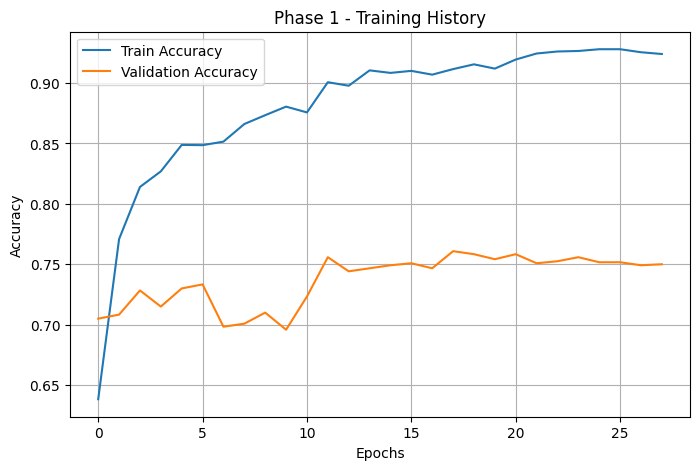

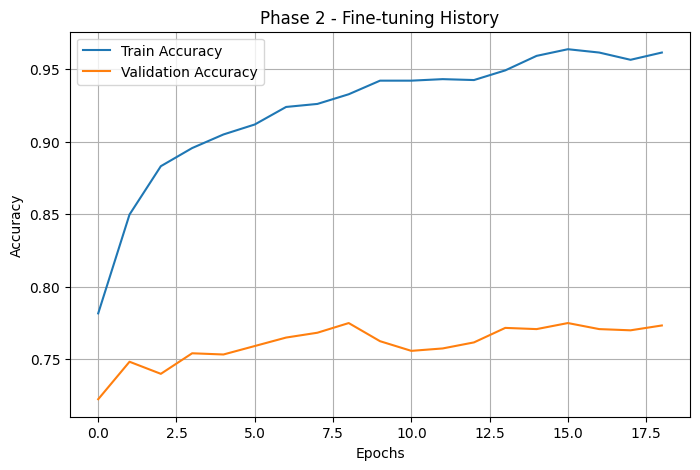

✅ Model saved at /content/final_combined_food_model.keras


In [3]:
# ===============================================
# 📦 IMPORTS AND SETUP
# ===============================================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os

# ===============================================
# 📂 DEFINE DATA PATH
# ===============================================
dataset_dir = '/content/combined_dataset'

# ===============================================
# 🧠 DATA GENERATORS
# ===============================================
datagen_train = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

datagen_val = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2
)

train_generator = datagen_train.flow_from_directory(
    dataset_dir,
    target_size=(160, 160),
    batch_size=24,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = datagen_val.flow_from_directory(
    dataset_dir,
    target_size=(160, 160),
    batch_size=24,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

num_classes = len(train_generator.class_indices)
print(f"✅ Found {num_classes} classes.")

# ===============================================
# 🏗️ MODEL ARCHITECTURE (EfficientNetB0)
# ===============================================
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(160, 160, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Freeze base layers first
for layer in base_model.layers:
    layer.trainable = False

# ===============================================
# ⚙️ COMPILE MODEL
# ===============================================
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ===============================================
# 🧩 CALLBACKS
# ===============================================
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_food_model.keras', monitor='val_accuracy', save_best_only=True)
]

# ===============================================
# 🚀 TRAIN (PHASE 1 - Frozen base)
# ===============================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=callbacks
)

# ===============================================
# 🔓 UNFREEZE AND FINE-TUNE (PHASE 2)
# ===============================================
for layer in base_model.layers[-100:]:  # Unfreeze last 100 layers
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('final_food_model.keras', monitor='val_accuracy', save_best_only=True)
]

fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=fine_tune_callbacks
)

# ===============================================
# 📊 PLOT TRAINING HISTORY
# ===============================================
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history, "Phase 1 - Training History")
plot_history(fine_tune_history, "Phase 2 - Fine-tuning History")

# ===============================================
# 💾 SAVE FINAL MODEL
# ===============================================
model.save("/content/final_combined_food_model.keras")
print("✅ Model saved at /content/final_combined_food_model.keras")
